# 04 – Bidding Evaluation: Newsvendor-Based Wind Power Trading

Dieses Notebook bewertet alle Forecasting-Modelle aus Notebook 03 **ökonomisch**.

## Entscheidungslogik

### Schicht 1 – Gewinnfunktion
$$\pi_t = p_{DA,t} \cdot b_t + p_{reBAP,t} \cdot (y_t - b_t)$$

### Schicht 2 – Newsvendor-Verlustfunktion
$$L_t = c_{under} \cdot \max(b_t - y_t, 0) + c_{over} \cdot \max(y_t - b_t, 0)$$

mit:
- $c_{under} = \mathbb{E}[\max(p_{reBAP} - p_{DA}, 0)]$ → Unterdeckung teuer wenn reBAP > DA
- $c_{over}  = \mathbb{E}[\max(p_{DA} - p_{reBAP}, 0)]$ → Überdeckung teuer wenn DA > reBAP

### Schicht 3 – Optimales Quantil
$$\tau^* = \frac{c_{under}}{c_{under} + c_{over}}$$

## Hinweis zu Day-Ahead-Preisen

Da keine separaten Day-Ahead-Marktpreise (EPEX) vorliegen, wird ein vereinfachtes Modell verwendet:  
**$p_{DA} = $ mittlerer reBAP über den Trainingszeitraum** (konstante Approximation).  
Dies ist eine bewusste Vereinfachung. In einer vollständigen Implementierung würden stündliche EPEX-Spot-Preise genutzt.

## Zentrale Forschungsfrage

```
Forecast → Bid → Profit / Newsvendor Loss
```

Ist das Modell mit bestem RMSE auch wirtschaftlich am besten?  
Können interpretierbare Modelle mit Black-Box-Modellen mithalten?

## 1. Setup und Imports

In [8]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Pfade
REBAP_DIR      = PROJECT_ROOT / "data" / "raw"/"Daten zu reBAP Preisen"          # passe ggf. an
FORECAST_DIR   = PROJECT_ROOT / "results" / "forecasts"
RESULTS_DIR    = PROJECT_ROOT / "results"
TABLES_DIR     = RESULTS_DIR / "tables"
FIGURES_DIR    = RESULTS_DIR / "figures"

for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/noahweis/wind_bidding_project


In [9]:
from src.bidding.newsvendor import compute_costs, optimal_quantile, loss, profit

## 2. reBAP-Daten laden und auf Stunden aggregieren

Die reBAP-Daten liegen im 15-Minuten-Raster vor (deutsches Format: Semikolon, Komma als Dezimaltrennzeichen).  
Hinweis: **2021 fehlt** in den vorhandenen Dateien.

Für das Bidding-Modell verwenden wir den Mittelwert aus `reBAP unterdeckt` und `reBAP ueberdeckt` pro Stunde.

In [10]:
def load_rebap_file(path: Path) -> pd.DataFrame:
    """Lädt eine reBAP-CSV (15-min, deutsches Format) und gibt einen sauberen DataFrame zurück."""
    df = pd.read_csv(
        path,
        sep=";",
        decimal=",",
        encoding="utf-8-sig",   # BOM entfernen
        usecols=["Datum", "von", "reBAP unterdeckt", "reBAP ueberdeckt"],
    )

    df["timestamp"] = pd.to_datetime(
        df["Datum"] + " " + df["von"],
        format="%d.%m.%Y %H:%M",
        errors="coerce",
    )

    df = df.dropna(subset=["timestamp"]).copy()
    df = df.rename(columns={
        "reBAP unterdeckt": "rebap_under",
        "reBAP ueberdeckt": "rebap_over",
    })

    # Mittlerer reBAP pro 15-min-Slot
    df["rebap"] = (df["rebap_under"] + df["rebap_over"]) / 2

    return df[["timestamp", "rebap", "rebap_under", "rebap_over"]]


# Alle Jahre einlesen
rebap_files = sorted(REBAP_DIR.glob("reBAP *.csv"))
print(f"Gefundene reBAP-Dateien: {len(rebap_files)}")
for f in rebap_files:
    print(" ", f.name)

rebap_raw = pd.concat(
    [load_rebap_file(f) for f in rebap_files],
    ignore_index=True,
).sort_values("timestamp").reset_index(drop=True)

print("\nreBAP 15-min Shape:", rebap_raw.shape)
print("Zeitraum:", rebap_raw["timestamp"].min(), "bis", rebap_raw["timestamp"].max())
rebap_raw.head()

Gefundene reBAP-Dateien: 10
  reBAP 2016.csv
  reBAP 2017.csv
  reBAP 2018.csv
  reBAP 2019.csv
  reBAP 2020.csv
  reBAP 2021.csv
  reBAP 2022.csv
  reBAP 2023.csv
  reBAP 2024.csv
  reBAP 2025.csv

reBAP 15-min Shape: (350688, 4)
Zeitraum: 2016-01-01 00:00:00 bis 2025-12-31 23:45:00


,timestamp,rebap,rebap_under,rebap_over
0,2016-01-01 00:00:00,-47.43,-47.43,-47.43
1,2016-01-01 00:15:00,78.73,78.73,78.73
2,2016-01-01 00:30:00,45.75,45.75,45.75
3,2016-01-01 00:45:00,37.41,37.41,37.41
4,2016-01-01 01:00:00,65.72,65.72,65.72


In [11]:
# Auf Stunden aggregieren (Mittelwert der 4 Slots pro Stunde)
rebap_hourly = (
    rebap_raw
    .set_index("timestamp")
    .resample("h")[["rebap", "rebap_under", "rebap_over"]]
    .mean()
    .reset_index()
)

print("reBAP stündlich Shape:", rebap_hourly.shape)
rebap_hourly.head()

reBAP stündlich Shape: (87672, 4)


,timestamp,rebap,rebap_under,rebap_over
0,2016-01-01 00:00:00,28.6150,28.6150,28.6150
1,2016-01-01 01:00:00,-0.8025,-0.8025,-0.8025
2,2016-01-01 02:00:00,53.8300,53.8300,53.8300
3,2016-01-01 03:00:00,45.1050,45.1050,45.1050
4,2016-01-01 04:00:00,20.6700,20.6700,20.6700


## 3. Forecast-Predictions laden

In [12]:
predictions = pd.read_csv(
    FORECAST_DIR / "predictions_day_ahead.csv",
    parse_dates=["timestamp"],
)

print("Predictions Shape:", predictions.shape)
print("Testzeitraum:", predictions["timestamp"].min(), "bis", predictions["timestamp"].max())
predictions.head()

Predictions Shape: (1282, 26)
Testzeitraum: 2016-11-08 11:00:00 bis 2016-12-31 23:00:00


,timestamp,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2016-11-08 11:00:00,0.691000,0.204000,0.378844,0.550077,0.376761,0.000459,0.019220,0.121133,0.507453,...,0.0,0.024389,0.147238,0.565281,1.186010,0.000000,0.046626,0.139566,0.357919,0.721249
1,2016-11-08 12:00:00,0.891500,0.163167,0.369516,0.571859,0.390204,0.000238,0.020119,0.126676,0.500573,...,0.0,0.015867,0.141552,0.577697,1.195322,0.009405,0.045151,0.140237,0.354500,0.729484
2,2016-11-08 13:00:00,0.553667,0.328833,0.384443,0.635096,0.390204,0.000542,0.027349,0.152061,0.554866,...,0.0,0.024389,0.147238,0.577697,1.254037,0.000217,0.046089,0.143744,0.369842,0.765838
3,2016-11-08 14:00:00,0.387833,0.030500,0.356833,0.610893,0.359497,0.000104,0.019665,0.123987,0.474217,...,0.0,0.012388,0.126687,0.487298,1.238272,0.000000,0.043410,0.140414,0.301876,0.718889
4,2016-11-08 15:00:00,0.306667,0.037000,0.362666,0.399496,0.341871,0.000330,0.023353,0.123172,0.433674,...,0.0,0.012663,0.126687,0.487298,1.055547,0.000000,0.048010,0.128213,0.261429,0.690694


## 4. Predictions mit reBAP mergen

In [13]:
df = predictions.merge(rebap_hourly, on="timestamp", how="inner")

print("Merged Shape:", df.shape)
missing = len(predictions) - len(df)
if missing > 0:
    warnings.warn(f"{missing} Stunden ohne reBAP-Daten wurden entfernt (z.B. 2021 fehlt).")

df.head()

Merged Shape: (1282, 29)


,timestamp,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90,rebap,rebap_under,rebap_over
0,2016-11-08 11:00:00,0.691000,0.204000,0.378844,0.550077,0.376761,0.000459,0.019220,0.121133,0.507453,...,0.565281,1.186010,0.000000,0.046626,0.139566,0.357919,0.721249,78.8725,78.8725,78.8725
1,2016-11-08 12:00:00,0.891500,0.163167,0.369516,0.571859,0.390204,0.000238,0.020119,0.126676,0.500573,...,0.577697,1.195322,0.009405,0.045151,0.140237,0.354500,0.729484,65.3450,65.3450,65.3450
2,2016-11-08 13:00:00,0.553667,0.328833,0.384443,0.635096,0.390204,0.000542,0.027349,0.152061,0.554866,...,0.577697,1.254037,0.000217,0.046089,0.143744,0.369842,0.765838,20.1675,20.1675,20.1675
3,2016-11-08 14:00:00,0.387833,0.030500,0.356833,0.610893,0.359497,0.000104,0.019665,0.123987,0.474217,...,0.487298,1.238272,0.000000,0.043410,0.140414,0.301876,0.718889,55.0775,55.0775,55.0775
4,2016-11-08 15:00:00,0.306667,0.037000,0.362666,0.399496,0.341871,0.000330,0.023353,0.123172,0.433674,...,0.487298,1.055547,0.000000,0.048010,0.128213,0.261429,0.690694,67.2375,67.2375,67.2375


## 5. Newsvendor-Kostenstruktur berechnen

Da keine separaten Day-Ahead-Preise vorliegen, wird $p_{DA}$ als konstanter Mittelwert des reBAP approximiert.

$$p_{DA} \approx \bar{p}_{reBAP}$$

Diese Vereinfachung bedeutet, dass $c_{under}$ und $c_{over}$ die Asymmetrie im reBAP-Profil widerspiegeln.

In [14]:
# p_DA als konstante Approximation (Mittelwert des reBAP über den Testzeitraum)
p_da_mean = float(df["rebap"].mean())
p_da      = np.full(len(df), p_da_mean)
p_rebap   = df["rebap"].to_numpy()

c_under, c_over = compute_costs(p_da, p_rebap)
tau_star        = optimal_quantile(c_under, c_over)

print(f"p_DA (Approximation):  {p_da_mean:.2f} EUR/MWh")
print(f"c_under:               {c_under:.4f} EUR/MWh")
print(f"c_over:                {c_over:.4f}  EUR/MWh")
print(f"τ* (optimales Quantil): {tau_star:.4f}")
print()
print("Interpretation:")
if tau_star > 0.5:
    print(f"  τ* > 0.5 → Unterdeckung ist teurer → konservativ mehr bieten")
elif tau_star < 0.5:
    print(f"  τ* < 0.5 → Überdeckung ist teurer → vorsichtig weniger bieten")
else:
    print(f"  τ* = 0.5 → symmetrische Kosten → Median als optimales Gebot")

p_DA (Approximation):  41.76 EUR/MWh
c_under:               15.8209 EUR/MWh
c_over:                15.8209  EUR/MWh
τ* (optimales Quantil): 0.5000

Interpretation:
  τ* < 0.5 → Überdeckung ist teurer → vorsichtig weniger bieten


## 6. Hilfsfunktionen für Bidding-Evaluation

In [15]:
def evaluate_bid(
    model_name: str,
    bid: np.ndarray,
    y_true: np.ndarray,
    p_da: np.ndarray,
    p_rebap: np.ndarray,
    c_under: float,
    c_over: float,
) -> dict:
    """Berechnet alle ökonomischen Kennzahlen für ein Gebots-Array."""
    bid = np.clip(bid, 0, None)   # sicherheitshalber clipping

    nv_loss  = loss(bid, y_true, c_under, c_over)
    profits  = profit(bid, y_true, p_da, p_rebap)

    return {
        "model":              model_name,
        "mean_profit":        float(np.mean(profits)),
        "total_profit":       float(np.sum(profits)),
        "mean_nv_loss":       float(np.mean(nv_loss)),
        "total_nv_loss":      float(np.sum(nv_loss)),
        "mean_abs_imbalance": float(np.mean(np.abs(y_true - bid))),
        "underbid_ratio":     float(np.mean(bid < y_true)),   # Anteil Unterdeckung
        "overbid_ratio":      float(np.mean(bid > y_true)),   # Anteil Überdeckung
        "_bid":               bid,
        "_profits":           profits,
        "_nv_loss":           nv_loss,
    }


y_true  = df["y_true"].to_numpy()
results = []   # sammelt alle Ergebnisse

## 7. Point Forecast Bidding

Bei Point Forecasts gilt: $b_t = \hat{y}_t$  
Das Modell bietet direkt seine Punktvorhersage — kein Quantil-Tuning möglich.

In [16]:
point_models = {
    "Persistence_24h":  df["persistence_24h"].to_numpy(),
    "Elastic_Net":      df["elastic_net"].to_numpy(),
    "Random_Forest":    df["random_forest"].to_numpy(),
    "Gradient_Boosting": df["gradient_boosting"].to_numpy(),
}

for name, bid in point_models.items():
    r = evaluate_bid(name, bid, y_true, p_da, p_rebap, c_under, c_over)
    results.append(r)
    print(f"{name:<25} mean_profit={r['mean_profit']:+.4f}  mean_nv_loss={r['mean_nv_loss']:.4f}")

Persistence_24h           mean_profit=+25.6013  mean_nv_loss=9.5533
Elastic_Net               mean_profit=+20.5872  mean_nv_loss=9.2376
Random_Forest             mean_profit=+21.5331  mean_nv_loss=10.2942
Gradient_Boosting         mean_profit=+20.8494  mean_nv_loss=9.9603


## 8. Probabilistic Forecast Bidding

Für probabilistische Modelle können zwei Strategien verglichen werden:

- **Median-Bid** ($b_t = Q_{0.5}$): naive Strategie, ignoriert Kostenasymmetrie
- **Newsvendor-Bid** ($b_t = Q_{\tau^*}$): optimale Strategie bei bekannter Kostenstruktur

Das nächste verfügbare Quantil zu $\tau^*$ wird verwendet.

In [17]:
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]

def get_quantile_bid(model_prefix: str, tau: float) -> np.ndarray:
    """
    Gibt den Bid für das nächste verfügbare Quantil zu tau zurück.
    Interpoliert linear zwischen den zwei nächsten Quantilen.
    """
    available = QUANTILES

    exact_col = f"{model_prefix}_q{int(tau * 100):02d}"
    if exact_col in df.columns:
        return df[exact_col].to_numpy()

    lower = max((q for q in available if q <= tau), default=available[0])
    upper = min((q for q in available if q >= tau), default=available[-1])

    col_low  = f"{model_prefix}_q{int(lower * 100):02d}"
    col_high = f"{model_prefix}_q{int(upper * 100):02d}"

    if lower == upper:
        return df[col_low].to_numpy()

    w = (tau - lower) / (upper - lower)
    return (1 - w) * df[col_low].to_numpy() + w * df[col_high].to_numpy()


prob_models = {
    "quantile_regression": "Quantile_Regression",
    "qrf":                  "QRF",
    "qgb":                  "Quantile_Gradient_Boosting",
    "qnn":                  "Quantile_Neural_Network",
}

for col_prefix, display_name in prob_models.items():
    # Median-Bid
    bid_median = get_quantile_bid(col_prefix, 0.5)
    r = evaluate_bid(
        f"{display_name} (q50)",
        bid_median, y_true, p_da, p_rebap, c_under, c_over,
    )
    results.append(r)

    # Newsvendor-Bid (τ*)
    bid_nv = get_quantile_bid(col_prefix, tau_star)
    r = evaluate_bid(
        f"{display_name} (τ*={tau_star:.2f})",
        bid_nv, y_true, p_da, p_rebap, c_under, c_over,
    )
    results.append(r)

    print(f"{display_name:<35} q50 nv_loss={results[-2]['mean_nv_loss']:.4f}  "
          f"τ* nv_loss={results[-1]['mean_nv_loss']:.4f}")

Quantile_Regression                 q50 nv_loss=9.1975  τ* nv_loss=9.1975
QRF                                 q50 nv_loss=10.0315  τ* nv_loss=10.0315
Quantile_Gradient_Boosting          q50 nv_loss=8.7388  τ* nv_loss=8.7388
Quantile_Neural_Network             q50 nv_loss=8.9058  τ* nv_loss=8.9058


## 9. Oracle-Benchmark

Der Oracle-Bid ist das optimale Gebot mit **vollständiger Information** über 
$y_t$:  $$b_t^{oracle} = y_t$$  
Er definiert die theoretische Obergrenze des Gewinns.

In [18]:
r_oracle = evaluate_bid(
    "Oracle (perfekt)",
    y_true.copy(), y_true, p_da, p_rebap, c_under, c_over,
)
results.append(r_oracle)
print(f"Oracle mean_profit={r_oracle['mean_profit']:+.4f}  mean_nv_loss={r_oracle['mean_nv_loss']:.4f}")

Oracle mean_profit=+25.7872  mean_nv_loss=0.0000


## 10. Ergebnistabelle

In [19]:
summary_cols = [
    "model", "mean_profit", "total_profit",
    "mean_nv_loss", "total_nv_loss",
    "mean_abs_imbalance", "underbid_ratio", "overbid_ratio",
]

summary = (
    pd.DataFrame([{c: r[c] for c in summary_cols} for r in results])
    .sort_values("mean_nv_loss")
    .reset_index(drop=True)
)

summary.to_csv(TABLES_DIR / "bidding_results_day_ahead.csv", index=False)
print("Gespeichert: bidding_results_day_ahead.csv")
display(summary)

Gespeichert: bidding_results_day_ahead.csv


,model,mean_profit,total_profit,mean_nv_loss,total_nv_loss,mean_abs_imbalance,underbid_ratio,overbid_ratio
0,Oracle (perfekt),25.787228,33059.226027,0.000000,0.000000,0.000000,0.000000,0.000000
1,Quantile_Gradient_Boosting (q50),20.625296,26441.629059,8.738759,11203.089591,0.552356,0.512480,0.487520
2,Quantile_Gradient_Boosting (τ*=0.50),20.625296,26441.629059,8.738759,11203.089591,0.552356,0.512480,0.487520
3,Quantile_Neural_Network (q50),21.119938,27075.760374,8.905833,11417.277477,0.562916,0.471139,0.528861
4,Quantile_Neural_Network (τ*=0.50),21.119938,27075.760374,8.905833,11417.277477,0.562916,0.471139,0.528861
5,Quantile_Regression (q50),20.758017,26611.777638,9.197517,11791.216831,0.581353,0.499220,0.485179
6,Quantile_Regression (τ*=0.50),20.758017,26611.777638,9.197517,11791.216831,0.581353,0.499220,0.485179
7,Elastic_Net,20.587156,26392.734540,9.237584,11842.582486,0.583885,0.364275,0.635725
8,Persistence_24h,25.601283,32820.845135,9.553297,12247.327338,0.603841,0.453978,0.466459
9,Gradient_Boosting,20.849437,26728.978697,9.960262,12769.055576,0.629564,0.351794,0.648206


## 11. Grafik: Kumulativer Newsvendor-Verlust über Zeit

Zeigt wie sich der Verlust der Modelle über den Testzeitraum akkumuliert.  
Ein flacherer Verlauf = besseres Modell.

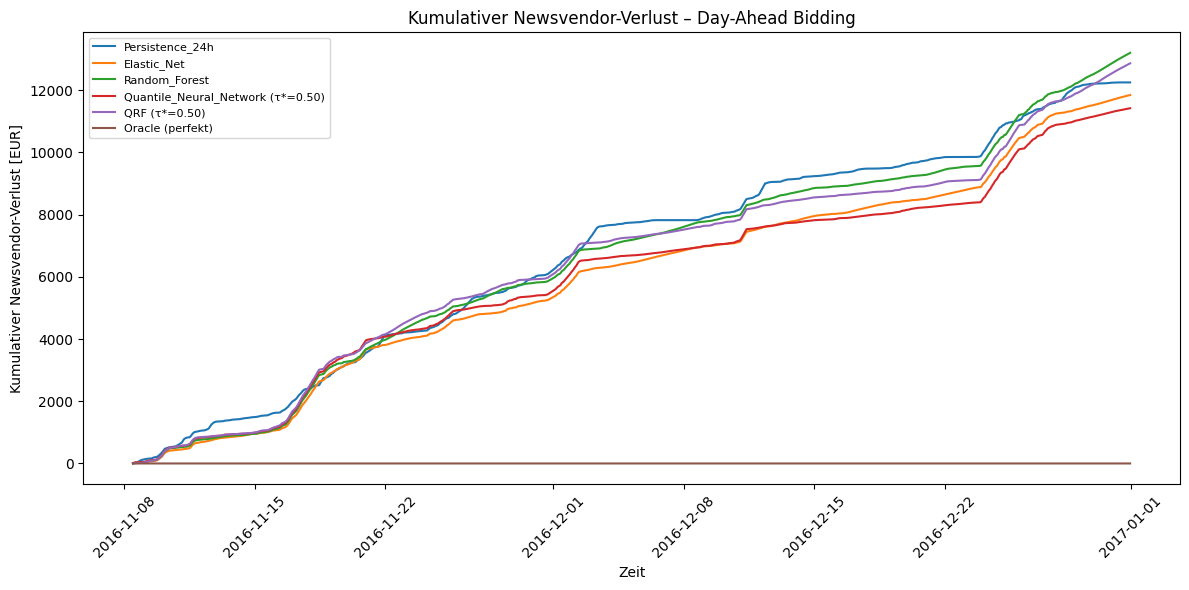

In [20]:
# Auswahl relevanter Modelle für die Grafik (nicht alle, sonst unübersichtlich)
plot_models = [
    "Persistence_24h",
    "Elastic_Net",
    "Random_Forest",
    f"Quantile_Neural_Network (τ*={tau_star:.2f})",
    f"QRF (τ*={tau_star:.2f})",
    "Oracle (perfekt)",
]

result_map = {r["model"]: r for r in results}

fig, ax = plt.subplots(figsize=(12, 6))

timestamps = df["timestamp"].values

for name in plot_models:
    if name not in result_map:
        continue
    cum_loss = np.cumsum(result_map[name]["_nv_loss"])
    ax.plot(timestamps, cum_loss, label=name)

ax.set_xlabel("Zeit")
ax.set_ylabel("Kumulativer Newsvendor-Verlust [EUR]")
ax.set_title("Kumulativer Newsvendor-Verlust – Day-Ahead Bidding")
ax.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cumulative_nv_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Grafik: Kumulativer Gewinn über Zeit

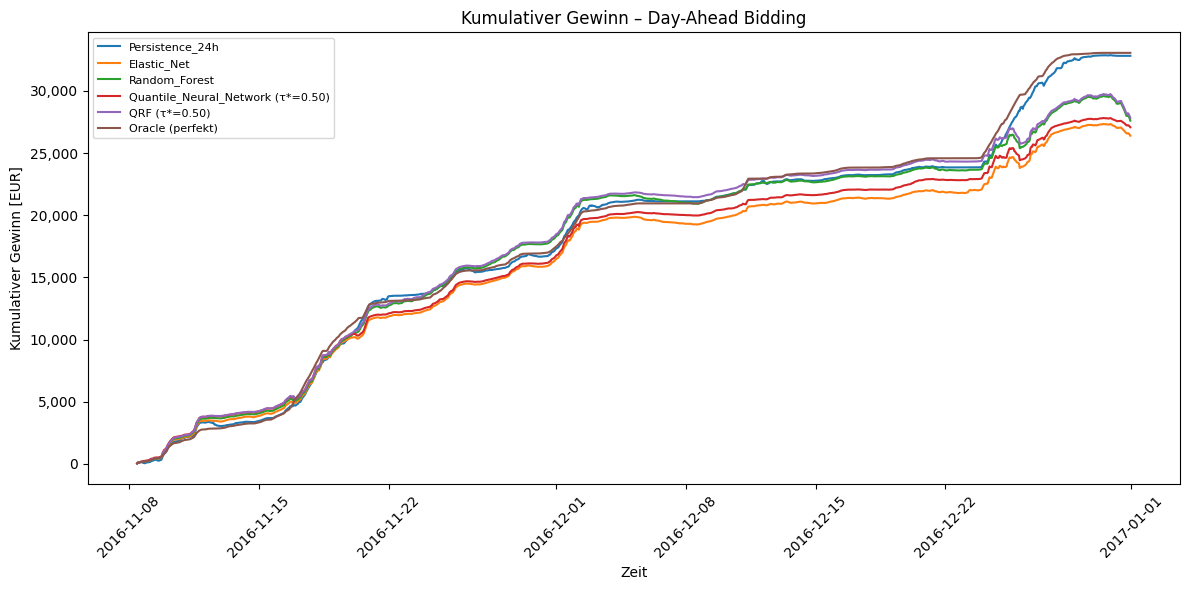

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

for name in plot_models:
    if name not in result_map:
        continue
    cum_profit = np.cumsum(result_map[name]["_profits"])
    ax.plot(timestamps, cum_profit, label=name)

ax.set_xlabel("Zeit")
ax.set_ylabel("Kumulativer Gewinn [EUR]")
ax.set_title("Kumulativer Gewinn – Day-Ahead Bidding")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cumulative_profit_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Grafik: Modellvergleich (mean Newsvendor Loss)

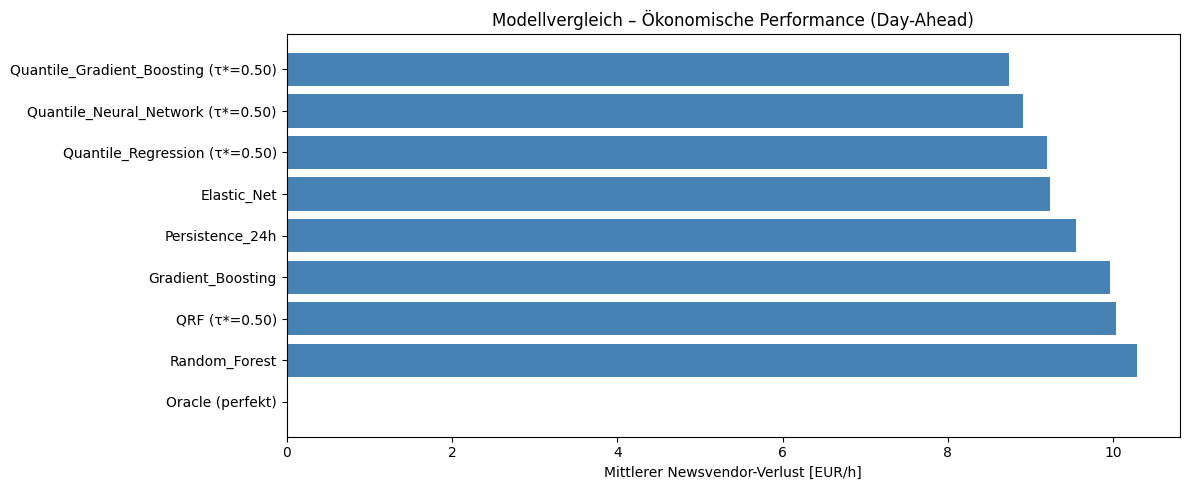

In [22]:
# Nur die Newsvendor-optimierten Bids der prob. Modelle + alle Point Forecasts
plot_df = summary[
    ~summary["model"].str.contains("q50") |
    summary["model"].isin(["Persistence_24h", "Elastic_Net", "Random_Forest", "Gradient_Boosting"])
].copy()

# Oracle ans Ende
oracle_row = plot_df[plot_df["model"] == "Oracle (perfekt)"]
plot_df = pd.concat([
    plot_df[plot_df["model"] != "Oracle (perfekt)"],
    oracle_row,
])

fig, ax = plt.subplots(figsize=(12, 5))
colors = [
    "steelblue" if "τ*" in m or m in ["Persistence_24h", "Elastic_Net", "Random_Forest", "Gradient_Boosting"]
    else "lightgray"
    for m in plot_df["model"]
]
colors[-1] = "gold"  # Oracle

ax.barh(plot_df["model"], plot_df["mean_nv_loss"], color=colors)
ax.set_xlabel("Mittlerer Newsvendor-Verlust [EUR/h]")
ax.set_title("Modellvergleich – Ökonomische Performance (Day-Ahead)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_nv_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Grafik: Bid vs. Actual (Beispielwoche)

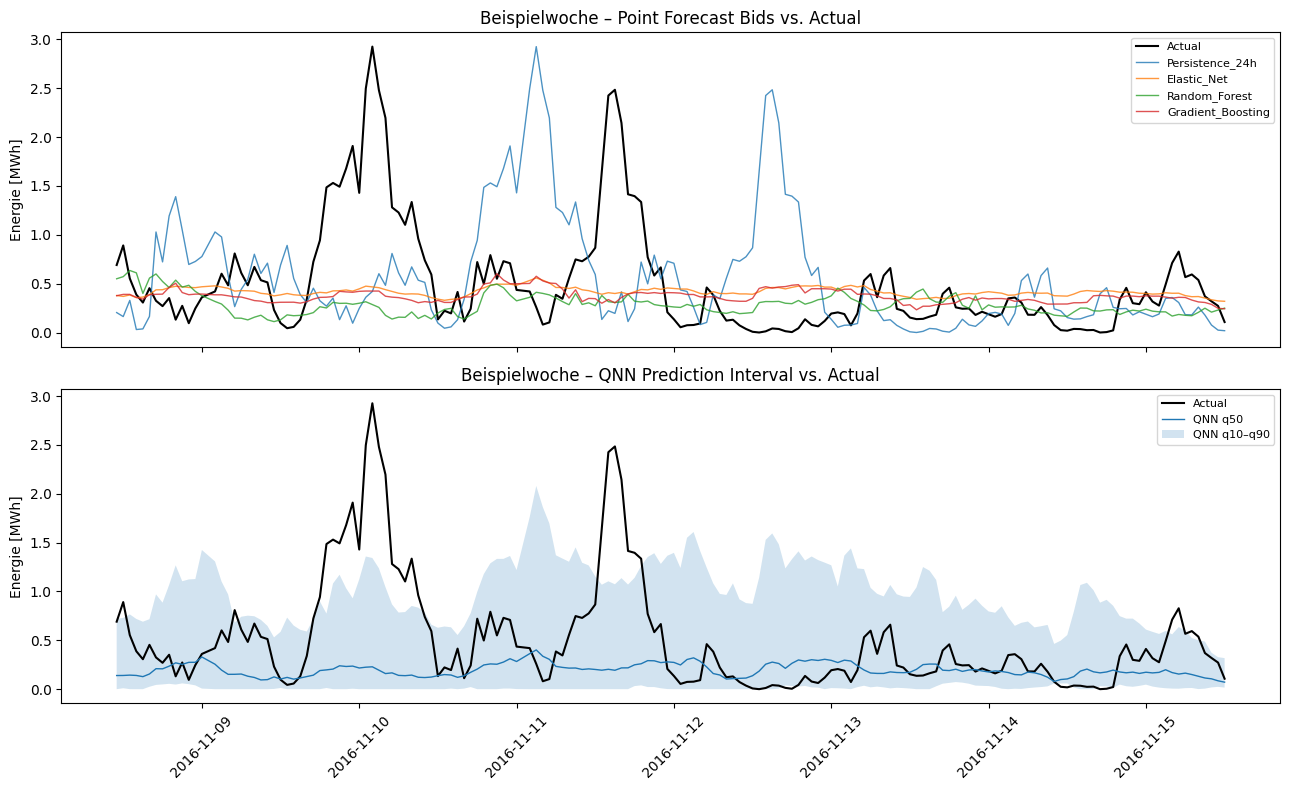

In [23]:
PLOT_HOURS = 168  # eine Woche

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

t = df["timestamp"].iloc[:PLOT_HOURS]

# Oben: Point Forecasts
axes[0].plot(t, y_true[:PLOT_HOURS], label="Actual", linewidth=1.5, color="black")
for name, bid_arr in point_models.items():
    axes[0].plot(t, bid_arr[:PLOT_HOURS], label=name, linewidth=1, alpha=0.8)
axes[0].set_ylabel("Energie [MWh]")
axes[0].set_title("Beispielwoche – Point Forecast Bids vs. Actual")
axes[0].legend(fontsize=8)

# Unten: Bestes prob. Modell mit Quantile-Band
best_prob = "qnn"   # ggf. anpassen nach Ergebnistabelle
axes[1].plot(t, y_true[:PLOT_HOURS], label="Actual", linewidth=1.5, color="black")
axes[1].plot(t, df[f"{best_prob}_q50"].iloc[:PLOT_HOURS], label="QNN q50", linewidth=1)
axes[1].fill_between(
    t,
    df[f"{best_prob}_q10"].iloc[:PLOT_HOURS],
    df[f"{best_prob}_q90"].iloc[:PLOT_HOURS],
    alpha=0.2, label="QNN q10–q90",
)
axes[1].set_ylabel("Energie [MWh]")
axes[1].set_title("Beispielwoche – QNN Prediction Interval vs. Actual")
axes[1].legend(fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bid_vs_actual_example_week.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Median vs. Newsvendor-Bid Vergleich

Zeigt wie viel die Newsvendor-optimale Quantilwahl gegenüber der naiven Median-Strategie bringt.

In [24]:
nv_comparison_rows = []

for col_prefix, display_name in prob_models.items():
    q50_name = f"{display_name} (q50)"
    nv_name  = f"{display_name} (τ*={tau_star:.2f})"

    if q50_name in result_map and nv_name in result_map:
        nv_comparison_rows.append({
            "model":           display_name,
            "nv_loss_q50":     result_map[q50_name]["mean_nv_loss"],
            "nv_loss_tau_star": result_map[nv_name]["mean_nv_loss"],
            "improvement":     result_map[q50_name]["mean_nv_loss"] - result_map[nv_name]["mean_nv_loss"],
        })

nv_comparison = pd.DataFrame(nv_comparison_rows).sort_values("improvement", ascending=False)
nv_comparison.to_csv(TABLES_DIR / "newsvendor_q50_vs_tau_star.csv", index=False)
display(nv_comparison)

,model,nv_loss_q50,nv_loss_tau_star,improvement
1,QRF,10.031503,10.031503,1.776357e-15
0,Quantile_Regression,9.197517,9.197517,0.000000e+00
2,Quantile_Gradient_Boosting,8.738759,8.738759,0.000000e+00
3,Quantile_Neural_Network,8.905833,8.905833,0.000000e+00


## 16. Zusammenfassung

Zentrale Befunde:

In [25]:
best_model    = summary.iloc[0]
worst_model   = summary[summary["model"] != "Oracle (perfekt)"].iloc[-1]
oracle_result = result_map["Oracle (perfekt)"]

print("=" * 60)
print("BIDDING EVALUATION – ZUSAMMENFASSUNG")
print("=" * 60)
print(f"\nτ* (optimales Newsvendor-Quantil): {tau_star:.4f}")
print(f"  c_under = {c_under:.4f} EUR/MWh")
print(f"  c_over  = {c_over:.4f}  EUR/MWh")
print()
print(f"Bestes Modell:    {best_model['model']}")
print(f"  mean NV Loss:  {best_model['mean_nv_loss']:.4f} EUR/h")
print(f"  total Profit:  {best_model['total_profit']:,.0f} EUR")
print()
print(f"Schlechtestes:    {worst_model['model']}")
print(f"  mean NV Loss:  {worst_model['mean_nv_loss']:.4f} EUR/h")
print()
print(f"Oracle (Obergrenze):")
print(f"  mean NV Loss:  {oracle_result['mean_nv_loss']:.4f} EUR/h")
print(f"  total Profit:  {oracle_result['total_profit']:,.0f} EUR")
print()
print("Vollständige Ergebnistabelle:")
display(summary)

BIDDING EVALUATION – ZUSAMMENFASSUNG

τ* (optimales Newsvendor-Quantil): 0.5000
  c_under = 15.8209 EUR/MWh
  c_over  = 15.8209  EUR/MWh

Bestes Modell:    Oracle (perfekt)
  mean NV Loss:  0.0000 EUR/h
  total Profit:  33,059 EUR

Schlechtestes:    Random_Forest
  mean NV Loss:  10.2942 EUR/h

Oracle (Obergrenze):
  mean NV Loss:  0.0000 EUR/h
  total Profit:  33,059 EUR

Vollständige Ergebnistabelle:


,model,mean_profit,total_profit,mean_nv_loss,total_nv_loss,mean_abs_imbalance,underbid_ratio,overbid_ratio
0,Oracle (perfekt),25.787228,33059.226027,0.000000,0.000000,0.000000,0.000000,0.000000
1,Quantile_Gradient_Boosting (q50),20.625296,26441.629059,8.738759,11203.089591,0.552356,0.512480,0.487520
2,Quantile_Gradient_Boosting (τ*=0.50),20.625296,26441.629059,8.738759,11203.089591,0.552356,0.512480,0.487520
3,Quantile_Neural_Network (q50),21.119938,27075.760374,8.905833,11417.277477,0.562916,0.471139,0.528861
4,Quantile_Neural_Network (τ*=0.50),21.119938,27075.760374,8.905833,11417.277477,0.562916,0.471139,0.528861
5,Quantile_Regression (q50),20.758017,26611.777638,9.197517,11791.216831,0.581353,0.499220,0.485179
6,Quantile_Regression (τ*=0.50),20.758017,26611.777638,9.197517,11791.216831,0.581353,0.499220,0.485179
7,Elastic_Net,20.587156,26392.734540,9.237584,11842.582486,0.583885,0.364275,0.635725
8,Persistence_24h,25.601283,32820.845135,9.553297,12247.327338,0.603841,0.453978,0.466459
9,Gradient_Boosting,20.849437,26728.978697,9.960262,12769.055576,0.629564,0.351794,0.648206
